# Utilities

Utility Functions per convertire i redpix dei dataframe in immagini e salvarle

### Plotting

Funzioni di Plotting, non Utilizzate

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as colors
import matplotlib.patches as mpatches


def simpleCUT (mask, dataset):

    """
    Function to apply a cut to a dataset
    :param mask: boolean mask
    :param dataset: dataset to be cut
    :return: cut dataset
    """

    return dataset[mask]

def CUT_HIST2D(mask, dataset1, dataset2, my_bins=150, my_range=None, description="Before and After the cut", my_xlabel="variabile 1", my_ylabel="variabile 2", my_cmap='inferno', confronto=False):

    """
    Function to plot a 2D histogram before and after a cut
    :param mask: boolean mask
    :param dataset1: first variable
    :param dataset2: second variable
    :param my_bins: number of bins
    :param my_range: range of the histogram
    :param description: description of the plot
    :param my_xlabel: x-axis label
    :param my_ylabel: y-axis label
    :param my_cmap: colormap
    :param confronto: if True, the range of the colorbar is the same for both plots
    :return: cut dataset
    """
    # Create subplots
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))

    # First plot
    h1 = axs[0].hist2d(dataset1, dataset2, bins=my_bins, norm=colors.LogNorm(), cmap = my_cmap, range=my_range)
    axs[0].set_xlabel(my_xlabel)
    axs[0].set_ylabel(my_ylabel)
    axs[0].grid(alpha=0.3)
    #fig.colorbar(axs[0].collections[0], ax=axs[0])

    # Se confronto è True, memorizziamo il range e i limiti della colorbar
    if confronto:
        vmin, vmax = h1[3].get_clim()  # Ottieni i limiti della colorbar
        if my_range is None:  # Se l'utente non ha fornito un range, prendiamo quello del primo istogramma
            xedges, yedges = h1[1], h1[2]
            my_range = [(xedges[0], xedges[-1]), (yedges[0], yedges[-1])]


    # Second plot
    norm = colors.LogNorm(vmin=vmin, vmax=vmax) if confronto else colors.LogNorm()
    h2 = axs[1].hist2d(dataset1[mask], dataset2[mask], bins=my_bins, norm=norm, cmap = my_cmap, range=my_range)
    axs[1].set_xlabel(my_xlabel)
    axs[1].set_ylabel(my_ylabel)
    axs[1].grid(alpha=0.3)
    #fig.colorbar(axs[1].collections[0], ax=axs[1])


    fig.colorbar(h1[3], ax=axs[0])
    fig.colorbar(h2[3], ax=axs[1])


    # Adjust layout
    #fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3)
    plt.tight_layout()
    plt.figtext(0.5, -0.1, description, ha="center", fontsize=13)
    plt.show()

    # Create a table with events before and after the cut
    events_before_cut = len(dataset1)
    events_after_cut = len(dataset1[mask])

    # Create a DataFrame to display the results
    cut_summary = pd.DataFrame({
        'Description': ['Events before cut', 'Events after cut', 'Efficiency of the cut'],
        'Count': [events_before_cut, events_after_cut, events_after_cut / events_before_cut]
    })

    # Display the table
    print(cut_summary)

    return dataset1[mask], dataset2[mask]



## Immagini da Redpix

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def make_event_image(xs, ys, zs,
                     mode='auto',
                     size=(64,64),
                     center=None,
                     fill_value=0,
                     show=False):
    """
    Build a 2D image from sparse pixels.

    Parameters
    ----------
    xs, ys, zs : array‐like
        Pixel x‐coords, y‐coords and intensities.
    mode : {'auto','fixed','cut','auto128'}
      - auto:   minimal bounding box
      - fixed:  resize bbox to `size`
      - cut:    window of size `size` centered on `center`
      - auto128: 128×128 image, event centered
    size : (height, width)
      Used for 'fixed' and 'cut'.
    center : (x_center, y_center)
      Required if mode=='cut'.
    fill_value : numeric
      Value for empty pixels.
    show : bool
      If True, immediately plt.show() the result.

    Returns
    -------
    img : 2D np.ndarray
    """
    xs = np.array(xs)
    ys = np.array(ys)
    zs = np.array(zs)

    if mode == 'auto':
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        H = y1 - y0 + 1
        W = x1 - x0 + 1
        img = np.full((H, W), fill_value, dtype=zs.dtype)
        rows = (ys - y0).astype(int)
        cols = (xs - x0).astype(int)
        img[rows, cols] = zs

    elif mode == 'fixed':
        auto = make_event_image(xs, ys, zs, mode='auto', fill_value=fill_value)
        im = Image.fromarray(auto)
        img = np.array(im.resize((size[1], size[0]), resample=Image.BILINEAR))

    elif mode == 'cut':
        if center is None:
            raise ValueError("In 'cut' mode you must pass center=(sc_xmean, sc_ymean)")
        xc, yc = map(int, center)
        h, w = size
        dx, dy = w//2, h//2
        x0, y0 = xc - dx, yc - dy
        img = np.full((h, w), fill_value, dtype=zs.dtype)
        for x, y, z in zip(xs, ys, zs):
            if x0 <= x < x0 + w and y0 <= y < y0 + h:
                img[int(y - y0), int(x - x0)] = z

    elif mode == 'auto128':
        # minimal bbox
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()
        W = x1 - x0 + 1
        H = y1 - y0 + 1
        # make 128×128 canvas
        canvas_size = 128
        img = np.full((canvas_size, canvas_size), fill_value, dtype=zs.dtype)
        # center offsets
        off_x = (canvas_size - W) // 2
        off_y = (canvas_size - H) // 2
        rows = (ys - y0).astype(int) + off_y
        cols = (xs - x0).astype(int) + off_x
        img[rows, cols] = zs

    else:
        raise ValueError("mode must be 'auto', 'fixed', 'cut' or 'auto128'")

    if show:
        plt.figure(figsize=(5,5))
        plt.imshow(img, origin='lower', cmap='inferno', aspect='equal')
        plt.colorbar(label='intensity')
        plt.tight_layout()
        plt.show()

    return img




def is_all_zero(img):
    # img is the raw float array from make_event_image (before colormap)
    return not np.any(img > 0)


import numpy as np

def has_interior_straight_zero_cut(img, min_len=60, margin=3, tol=0):
    """
    Returns True if there's a long, straight interior cut (horizontal or vertical)
    where pixels jump to zero along a constant row/col, away from the image edges.

    - min_len: minimum contiguous run length (in pixels) to call it a cut.
    - margin: how many pixels from each border still count as 'edge' (ignore there).
    - tol: allow small +/- tolerance when comparing the row/col index (0 = perfectly flat).
    """
    m = (img > 0).astype(np.uint8)
    H, W = m.shape

    def longest_run_of_constant(vals):
        max_run = run = 0
        prev = None
        for v in vals:
            if v < 0:                # -1 means no valid edge in this row/col
                run, prev = 0, None
                continue
            if prev is None or abs(v - prev) <= tol:
                run += 1
            else:
                max_run = max(max_run, run)
                run = 1
            prev = v
        return max(max_run, run)

    # ---- Horizontal cut: nonzero above, zero below (flat "roof") ----
    y_edge = np.full(W, -1, dtype=int)
    for x in range(W):
        ys = np.flatnonzero(m[:, x])
        if ys.size == 0:
            continue
        y = ys.max()                               # last nonzero from top
        if margin < y < H - 1 - margin and m[y, x] and (m[y + 1, x] == 0):
            y_edge[x] = y
    if longest_run_of_constant(y_edge) >= min_len:
        return True

    # ---- Horizontal cut: zero above, nonzero below (flat "floor") ----
    y_edge[:] = -1
    for x in range(W):
        ys = np.flatnonzero(m[:, x])
        if ys.size == 0:
            continue
        y = ys.min()                               # first nonzero from top
        if margin < y < H - margin and (m[y - 1, x] == 0) and m[y, x]:
            y_edge[x] = y - 1
    if longest_run_of_constant(y_edge) >= min_len:
        return True

    # ---- Vertical cut: nonzero left, zero right ----
    x_edge = np.full(H, -1, dtype=int)
    for y in range(H):
        xs = np.flatnonzero(m[y, :])
        if xs.size == 0:
            continue
        x = xs.max()
        if margin < x < W - 1 - margin and m[y, x] and (m[y, x + 1] == 0):
            x_edge[y] = x
    if longest_run_of_constant(x_edge) >= min_len:
        return True

    # ---- Vertical cut: zero left, nonzero right ----
    x_edge[:] = -1
    for y in range(H):
        xs = np.flatnonzero(m[y, :])
        if xs.size == 0:
            continue
        x = xs.min()
        if margin < x < W - margin and (m[y, x - 1] == 0) and m[y, x]:
            x_edge[y] = x - 1
    if longest_run_of_constant(x_edge) >= min_len:
        return True

    return False



def save_all_event_images(df, output_folder,
                          mode='auto',
                          size=(100,100),
                          center_cols=('sc_xmean','sc_ymean')):
    """
    Loop over df rows, make images, and save them as PNGs.
    For mode=='auto128', skip events whose bbox dims <25 or >100,
    and count how many are skipped.
    """
    os.makedirs(output_folder, exist_ok=True)
    skipped = 0
    saved = 0

    for idx, row in df.iterrows():
        xs = np.array(row['new_redpix_ix'])
        ys = np.array(row['new_redpix_iy'])
        zs = np.array(row['new_redpix_iz'])
        run = row['run']
        event = row['event']
        scintegral = row['sc_integral']

        if mode == 'cut':
            center = (row[center_cols[0]], row[center_cols[1]])
        else:
            center = None

        # size check for auto128
        if mode == 'auto128':
            W = xs.max() - xs.min() + 1
            H = ys.max() - ys.min() + 1
            if W < 20 or H < 20 or W > 150 or H > 150:
                skipped += 1
                continue

        img = make_event_image(xs, ys, zs,
                               mode=mode,
                               size=size,
                               center=center,
                               show=False)
        if is_all_zero(img):
            skipped += 1
            continue
        if has_interior_straight_zero_cut(img, min_len=20, margin=5, tol=0):
            skipped += 1
            continue

        fn = os.path.join(output_folder, f"run{run}_event{event}_scint{scintegral:.0f}.png")
        plt.imsave(fn, img, cmap='inferno', origin='lower')
        saved += 1

    print(f"Saved {saved} images to '{output_folder}'.")
    if mode == 'auto128':
        print(f"Skipped {skipped} events due to size constraints (dims <20 or >150)")
    print(f"Skipped {skipped} events with interior straight zero cuts. or all-zero images.")


Funzioni per plot e selezione poligoni di interesse

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.path import Path

def polygon_path(points):
    """
    points: sequence of (x_keV, y_keV_per_hit).
    Returns a closed matplotlib Path in data coordinates.
    """
    pts = np.asarray(points, dtype=float)
    if pts.shape[0] < 3:
        raise ValueError("Polygon needs at least 3 points.")
    # close polygon if not closed
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])
    # build corresponding Path codes
    codes = np.full(len(pts), Path.LINETO, dtype=Path.code_type)
    codes[0] = Path.MOVETO
    return Path(pts, codes)

def points_in_polygon_mask(x, y, poly_path):
    """
    x, y: 1D arrays (same length). poly_path: Path in data coords.
    Returns boolean mask of points strictly inside the polygon (no border).
    """
    xy = np.column_stack([x, y])
    mask = poly_path.contains_points(xy)
    # treat NaNs as outside
    bad = ~np.isfinite(x) | ~np.isfinite(y)
    mask[bad] = False
    return mask


# Estrazione Immagini 

## AmBe

### Lettura df

In [6]:
import os
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

param_list = ['run', 'event', 'pedestal_run', 'cmos_integral', 'cmos_mean', 'cmos_rms',
              't_DBSCAN', 't_variables', 'lp_len', 't_pedsub', 't_saturation', 't_zerosup',
              't_xycut', 't_rebin', 't_medianfilter', 't_noisered', 'nSc', 'sc_size', 'sc_nhits',
              'sc_integral', 'sc_corrintegral', 'sc_rms', 'sc_energy', 'sc_pathlength',
              'sc_theta', 'sc_length', 'sc_width', 'sc_longrms', 'sc_latrms', 'sc_lfullrms',
              'sc_tfullrms', 'sc_lp0amplitude', 'sc_lp0prominence', 'sc_lp0fwhm', 'sc_lp0mean',
              'sc_tp0fwhm', 'sc_xmean', 'sc_ymean', 'sc_xmax', 'sc_xmin', 'sc_ymax', 'sc_ymin',
              'sc_pearson', 'sc_tgaussamp', 'sc_tgaussmean', 'sc_tgausssigma', 'sc_tchi2',
              'sc_tstatus', 'sc_lgaussamp', 'sc_lgaussmean', 'sc_lgausssigma', 'sc_lchi2', 'sc_lstatus',
              'Lime_pressure', 'Atm_pressure', 'Lime_temperature', 'Atm_temperature', 'Humidity',
              'Mixture_Density',  'sc_redpixIdx','nRedpix','redpix_ix','redpix_iy','redpix_iz']



In [7]:
#df = pd.read_parquet("/Volumes/Oppedix_SSD/Dataframe_creator_run_5/Ambe_HighGain/combined_filtered_NO_RED.parquet")
df = pd.read_parquet('/Volumes/Oppedix_SSD/Dataframe_creator_run_5/Ambe_HighGain/split_by_run_ranges/chunk_03_99836-100023.parquet')

print("Max run:", df['run'].max())
print("Min run:", df['run'].min())

Max run: 100023
Min run: 99836


In [8]:
df['rho'] = df['sc_rms'] / pd.to_numeric(df['sc_nhits'], errors='coerce')


In [9]:
# Store both conversion factors as constants
CONVERSION_FACTOR_AMBE = 0.000577090214042

# Store both exposure factors as constants
EXPOSURE_FACTOR_AMBE = 246085



In [10]:
#Add sc_integral*conversion_factor and sc_integral/sc_nhits to both dataframes
df['sc_en_calib'] = df['sc_integral'] * CONVERSION_FACTOR_AMBE
df['density'] = df['sc_en_calib'] / df['sc_nhits']
df['density_from_sc'] = df['sc_integral'] / df['sc_nhits']


 

### Dataset creation

Plot della zona di interesse che stiamo selezionando

(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]),
 [Text(0, 0.0, '0.00'),
  Text(0, 0.01, '0.01'),
  Text(0, 0.02, '0.02'),
  Text(0, 0.03, '0.03'),
  Text(0, 0.04, '0.04'),
  Text(0, 0.05, '0.05'),
  Text(0, 0.06, '0.06'),
  Text(0, 0.07, '0.07')])

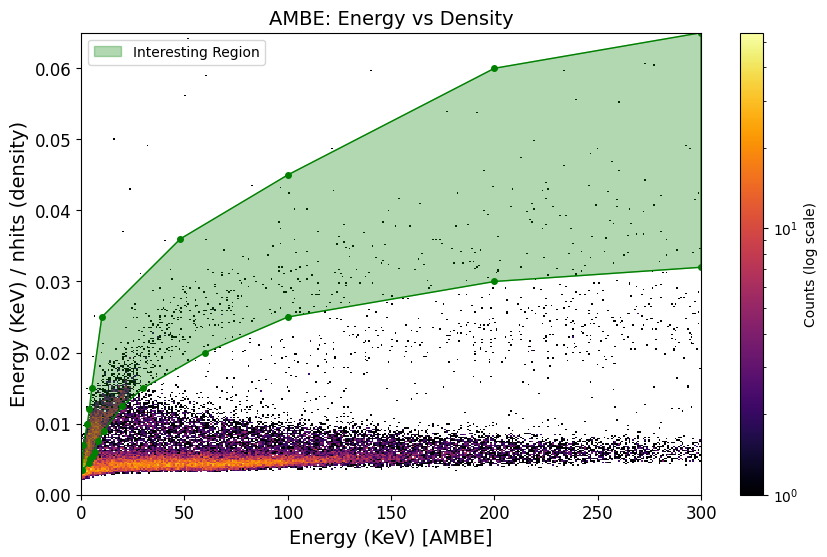

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# AMBE dataset
energy_AMBE  = df['sc_en_calib']
nhits_AMBE   = df['sc_nhits']
density_AMBE =  df['density']

plt.figure(figsize=(10, 6))

# AMBE

plt.hist2d(
    energy_AMBE,
    density_AMBE,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 300), (0, 0.065))
)
plt.xlabel("Energy (KeV) [AMBE]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("AMBE: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')

# Highlight Selection region
poly_AMBE = [
    (0.5, 0.0035),
    (1, 0.007),
    (3, 0.010),
    (4, 0.012),
    (5.13, 0.015),
    ( 10.0, 0.025),
    (48.0, 0.036),
    ( 100.0, 0.045),
    ( 200.0, 0.060),
    ( 300.0, 0.065),
    ( 300.0, 0.032),
    ( 200.0, 0.03),
    ( 100.0, 0.025),
    ( 60.0, 0.02),
    ( 30.0, 0.015),
    ( 20.0, 0.0125),
    (11, 0.009),
    (8.0, 0.0075),
    (6.5, 0.006),
    (5.5, 0.0055),
    (4.5, 0.005),
    (4, 0.0045),
]
path_AMBE = polygon_path(poly_AMBE)

verts_AMBE = path_AMBE.vertices
plt.fill(verts_AMBE[:,0], verts_AMBE[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_AMBE[:,0], verts_AMBE[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)




Zoom per assicurarci di selezionare la zona rilevante anche a basse energie

(array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.005, '0.005'),
  Text(0, 0.01, '0.010'),
  Text(0, 0.015, '0.015'),
  Text(0, 0.02, '0.020'),
  Text(0, 0.025, '0.025'),
  Text(0, 0.03, '0.030'),
  Text(0, 0.035, '0.035'),
  Text(0, 0.04, '0.040')])

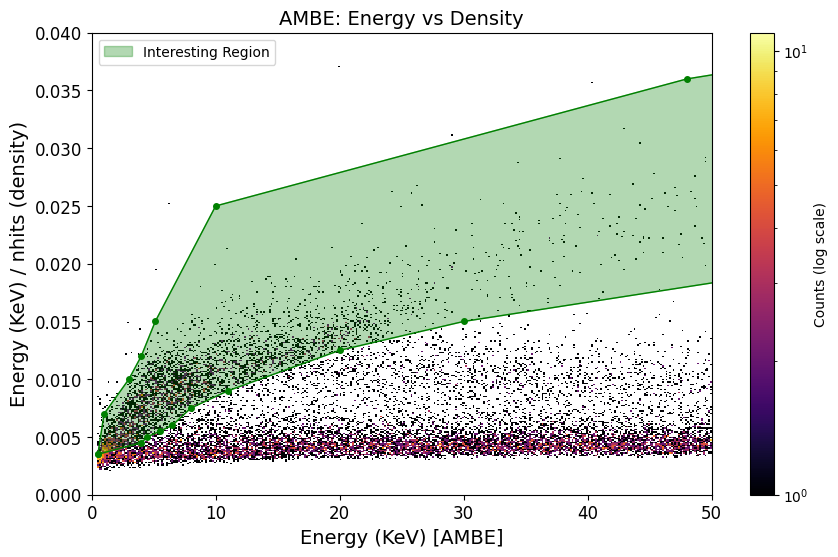

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# AMBE dataset
energy_AMBE  = df['sc_en_calib']
nhits_AMBE   = df['sc_nhits']
density_AMBE =  df['density']

plt.figure(figsize=(10, 6))

# AMBE

plt.hist2d(
    energy_AMBE,
    density_AMBE,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 50), (0, 0.040))
)
plt.xlabel("Energy (KeV) [AMBE]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("AMBE: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')



path_AMBE = polygon_path(poly_AMBE)

verts_AMBE = path_AMBE.vertices
plt.fill(verts_AMBE[:,0], verts_AMBE[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_AMBE[:,0], verts_AMBE[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)




Zoom Ulteriore

(array([0.   , 0.002, 0.004, 0.006, 0.008, 0.01 , 0.012, 0.014, 0.016]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.002, '0.002'),
  Text(0, 0.004, '0.004'),
  Text(0, 0.006, '0.006'),
  Text(0, 0.008, '0.008'),
  Text(0, 0.01, '0.010'),
  Text(0, 0.012, '0.012'),
  Text(0, 0.014, '0.014'),
  Text(0, 0.016, '0.016')])

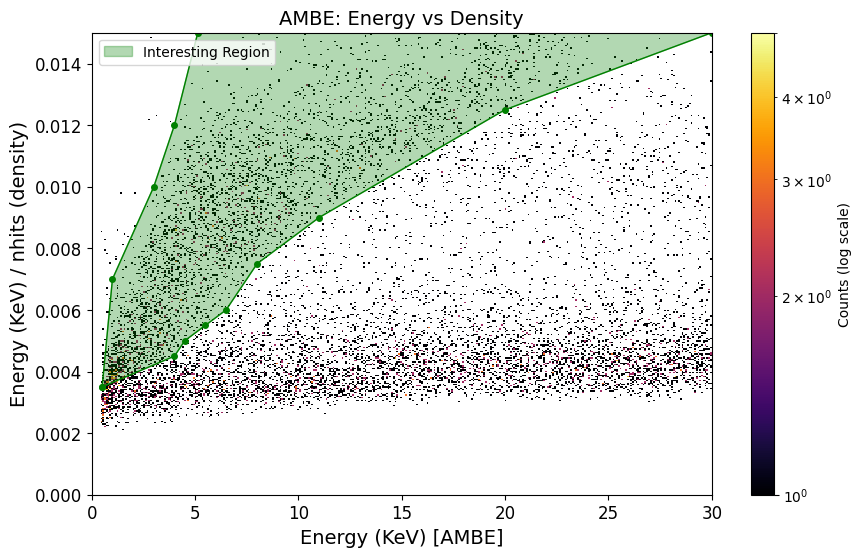

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# AMBE dataset
energy_AMBE  = df['sc_en_calib']
nhits_AMBE   = df['sc_nhits']
density_AMBE =  df['density']

plt.figure(figsize=(10, 6))

# AMBE

plt.hist2d(
    energy_AMBE,
    density_AMBE,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 30), (0, 0.015))
)
plt.xlabel("Energy (KeV) [AMBE]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("AMBE: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')



path_AMBE = polygon_path(poly_AMBE)

verts_AMBE = path_AMBE.vertices
plt.fill(verts_AMBE[:,0], verts_AMBE[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_AMBE[:,0], verts_AMBE[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)




In [14]:
mask_AMBE = points_in_polygon_mask(
    energy_AMBE.values, 
    density_AMBE.values, 
    path_AMBE
)

df_selected = df[mask_AMBE].copy()



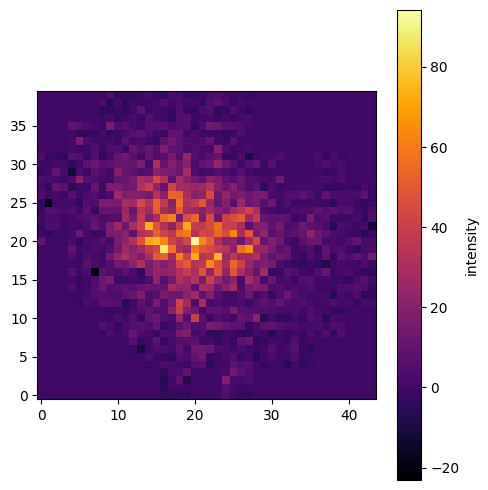

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [15]:


# 2) show one example in auto mode
make_event_image(
    df_selected.iloc[10]['new_redpix_ix'],
    df_selected.iloc[10]['new_redpix_iy'],
    df_selected.iloc[10]['new_redpix_iz'],
    mode='auto', show=True
)


In [16]:
   
# Save centered 128×128 auto images, skipping too‐small or too‐large events
save_all_event_images(
    df_selected,
    output_folder='AmBe_images_test',
    mode='cut',
    size=(128,128),
    center_cols=('sc_xmean','sc_ymean')
)


Saved 3381 images to 'AmBe_images_test'.
Skipped 1312 events with interior straight zero cuts. or all-zero images.


## STD

In [4]:
#df = pd.read_parquet("/Volumes/Oppedix_SSD/AMBE5_DATA/std_runs_near_HG/nored_combined_filtered.parquet")
df = pd.read_parquet('/Volumes/Oppedix_SSD/AMBE5_DATA/std_runs_near_HG/split_by_run_ranges/chunk_09_100905-100999.parquet') 

print("Max run:", df['run'].max())
print("Min run:", df['run'].min())

Max run: 100999
Min run: 100905


In [5]:
df['rho'] = df['sc_rms'] / pd.to_numeric(df['sc_nhits'], errors='coerce')


In [6]:
CONVERSION_FACTOR_STD = 0.000512964171610
EXPOSURE_FACTOR_STD = 351430 


In [7]:
#Add sc_integral*conversion_factor and sc_integral/sc_nhits to both dataframes
df['sc_en_calib'] = df['sc_integral'] * CONVERSION_FACTOR_STD
df['density'] = df['sc_en_calib'] / df['sc_nhits']
df['density_from_sc'] = df['sc_integral'] / df['sc_nhits']


 

(array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07]),
 [Text(0, 0.0, '0.00'),
  Text(0, 0.01, '0.01'),
  Text(0, 0.02, '0.02'),
  Text(0, 0.03, '0.03'),
  Text(0, 0.04, '0.04'),
  Text(0, 0.05, '0.05'),
  Text(0, 0.06, '0.06'),
  Text(0, 0.07, '0.07')])

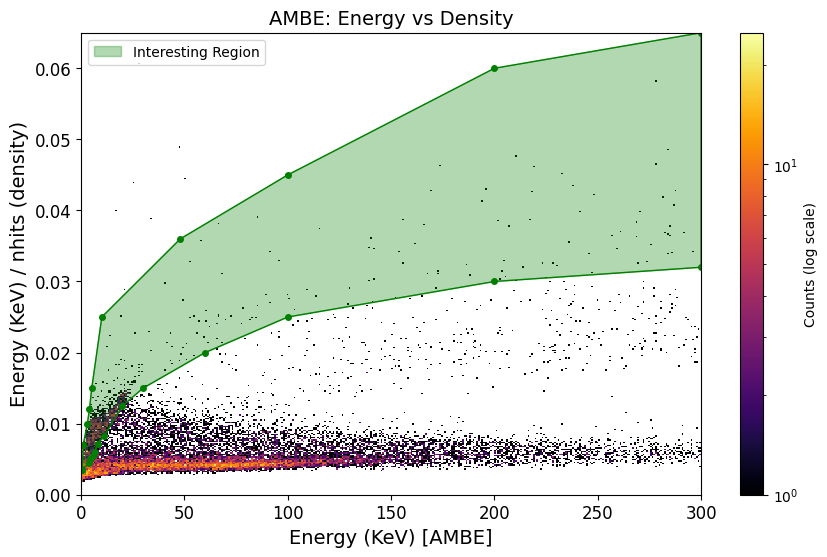

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


energy_AMBE  = df['sc_en_calib']
nhits_AMBE   = df['sc_nhits']
density_AMBE =  df['density']

plt.figure(figsize=(10, 6))

# AMBE

plt.hist2d(
    energy_AMBE,
    density_AMBE,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 300), (0, 0.065))
)
plt.xlabel("Energy (KeV) [AMBE]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("AMBE: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')

# Highlight Selection region
poly_AMBE = [
    (0.5, 0.0035),
    (1, 0.007),
    (3, 0.010),
    (4, 0.012),
    (5.13, 0.015),
    ( 10.0, 0.025),
    (48.0, 0.036),
    ( 100.0, 0.045),
    ( 200.0, 0.060),
    ( 300.0, 0.065),
    ( 300.0, 0.032),
    ( 200.0, 0.03),
    ( 100.0, 0.025),
    ( 60.0, 0.02),
    ( 30.0, 0.015),
    ( 20.0, 0.0125),
    (11, 0.0082),
    (8.0, 0.0072),
    (6.5, 0.006),
    (5.5, 0.0055),
    (4.5, 0.005),
    (4, 0.0045),
]
path_AMBE = polygon_path(poly_AMBE)

verts_AMBE = path_AMBE.vertices
plt.fill(verts_AMBE[:,0], verts_AMBE[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_AMBE[:,0], verts_AMBE[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)




(array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.005, '0.005'),
  Text(0, 0.01, '0.010'),
  Text(0, 0.015, '0.015'),
  Text(0, 0.02, '0.020'),
  Text(0, 0.025, '0.025'),
  Text(0, 0.03, '0.030'),
  Text(0, 0.035, '0.035'),
  Text(0, 0.04, '0.040')])

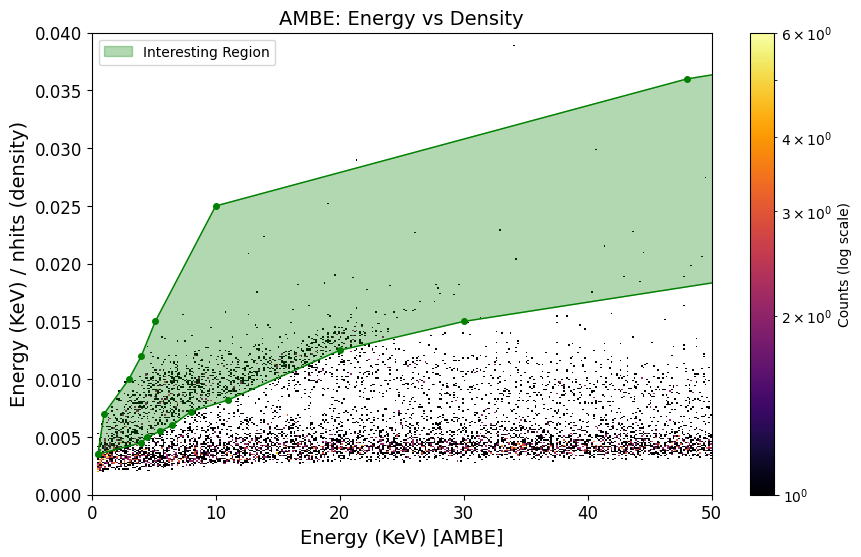

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# AMBE dataset
energy_AMBE  = df['sc_en_calib']
nhits_AMBE   = df['sc_nhits']
density_AMBE =  df['density']

plt.figure(figsize=(10, 6))

# AMBE

plt.hist2d(
    energy_AMBE,
    density_AMBE,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 50), (0, 0.040))
)
plt.xlabel("Energy (KeV) [AMBE]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("AMBE: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')



path_AMBE = polygon_path(poly_AMBE)

verts_AMBE = path_AMBE.vertices
plt.fill(verts_AMBE[:,0], verts_AMBE[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_AMBE[:,0], verts_AMBE[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)




(array([0.   , 0.002, 0.004, 0.006, 0.008, 0.01 , 0.012, 0.014, 0.016]),
 [Text(0, 0.0, '0.000'),
  Text(0, 0.002, '0.002'),
  Text(0, 0.004, '0.004'),
  Text(0, 0.006, '0.006'),
  Text(0, 0.008, '0.008'),
  Text(0, 0.01, '0.010'),
  Text(0, 0.012, '0.012'),
  Text(0, 0.014, '0.014'),
  Text(0, 0.016, '0.016')])

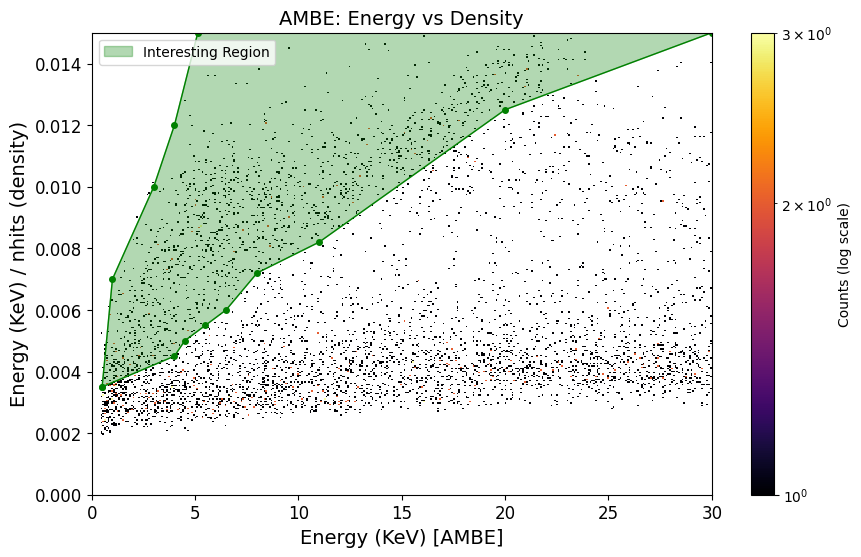

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# AMBE dataset
energy_AMBE  = df['sc_en_calib']
nhits_AMBE   = df['sc_nhits']
density_AMBE =  df['density']

plt.figure(figsize=(10, 6))

# AMBE

plt.hist2d(
    energy_AMBE,
    density_AMBE,
    bins=350,
    norm=mcolors.LogNorm(),
    cmap='inferno',
    range=((0, 30), (0, 0.015))
)
plt.xlabel("Energy (KeV) [AMBE]",fontsize=14)
plt.ylabel("Energy (KeV) / nhits (density)",fontsize=14)
plt.title("AMBE: Energy vs Density",fontsize=14)
plt.colorbar(label='Counts (log scale)')



path_AMBE = polygon_path(poly_AMBE)

verts_AMBE = path_AMBE.vertices
plt.fill(verts_AMBE[:,0], verts_AMBE[:,1], alpha=0.3, color='green', label='Interesting Region')
# (optional) draw the vertices to verify alignment
plt.plot(verts_AMBE[:,0], verts_AMBE[:,1], marker='o', linestyle='-', lw=1.0, ms=4, color='green')

plt.legend(loc='upper left', fontsize='medium')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)




In [11]:
mask_AMBE = points_in_polygon_mask(
    energy_AMBE.values, 
    density_AMBE.values, 
    path_AMBE
)

df_selected = df[mask_AMBE].copy()



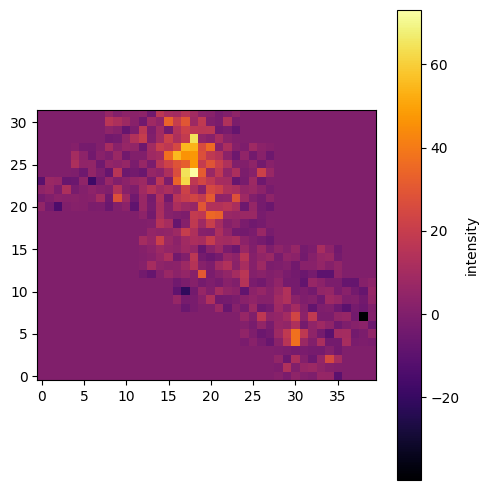

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [12]:


# 2) show one example in auto mode
make_event_image(
    df_selected.iloc[10]['new_redpix_ix'],
    df_selected.iloc[10]['new_redpix_iy'],
    df_selected.iloc[10]['new_redpix_iz'],
    mode='auto', show=True
)


In [13]:
   
# Save centered 128×128 auto images, skipping too‐small or too‐large events
save_all_event_images(
    df_selected,
    output_folder='STD_images_test',
    mode='cut',
    size=(128,128),
    center_cols=('sc_xmean','sc_ymean')
)


Saved 1204 images to 'STD_images_test'.
Skipped 354 events with interior straight zero cuts. or all-zero images.
